# White Hat / Black Hat: CO2 per Flight

This notebook focuses on the visualization ethics pair used in the final webpage. Both charts use the same yearly CO2-per-flight data. The black-hat version uses a truncated axis to exaggerate the visual change, while the white-hat version uses a proportional scale to show the same trend more honestly.


## 1. Setup


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

In [12]:
def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "data").exists():
            return path
    raise RuntimeError("Could not find project root")


PROJECT_ROOT = find_project_root()
CLEAN_DIR = PROJECT_ROOT / "data" / "clean"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)


def save_figure(fig, name: str) -> None:
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")

In [13]:
# palette from european_aviation_final.html design tokens
BLUE  = "#537D96"
RED   = "#BF4646"
DARK  = "#2C2F33"
MUTED = "#72777C"
LINE  = "#E3E6E8"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   LINE,
    "axes.linewidth":   0.8,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.labelcolor":  DARK,
    "axes.labelsize":   9,
    "axes.labelpad":    8,
    "axes.titlesize":   14,
    "axes.titleweight": "bold",
    "axes.titlecolor":  DARK,
    "axes.titlepad":    12,
    "xtick.color":      MUTED,
    "xtick.labelsize":  9,
    "ytick.color":      MUTED,
    "ytick.labelsize":  9,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "font.family":      "sans-serif",
    "figure.dpi":       130,
})


## 2. Data


In [14]:
df_state = pd.read_csv(CLEAN_DIR / "emission_state_clean.csv", parse_dates=["DATE"])

CODE2NAME = {
    "AL": "Albania", "AM": "Armenia", "AT": "Austria", "AZ": "Azerbaijan",
    "BA": "Bosnia", "BE": "Belgium", "BG": "Bulgaria", "CH": "Switzerland",
    "CY": "Cyprus", "CZ": "Czechia", "DE": "Germany", "DK": "Denmark",
    "EE": "Estonia", "ES": "Spain", "FI": "Finland", "FR": "France",
    "GB": "UK", "GE": "Georgia", "GR": "Greece", "HR": "Croatia",
    "HU": "Hungary", "IE": "Ireland", "IL": "Israel", "IS": "Iceland",
    "IT": "Italy", "LT": "Lithuania", "LU": "Luxembourg", "LV": "Latvia",
    "MA": "Morocco", "MD": "Moldova", "ME": "Montenegro", "MK": "Macedonia",
    "MT": "Malta", "NL": "Netherlands", "NO": "Norway", "PL": "Poland",
    "PT - Lisbon FIR": "Portugal", "PT - Santa Maria FIR": "PT Azores",
    "RO": "Romania", "RS": "Serbia", "SE": "Sweden", "SI": "Slovenia",
    "SK": "Slovakia", "TR": "Turkey", "UA": "Ukraine",
}


## 3. CO2 per flight over time: truthful and misleading scales

Both plots use the same yearly data: total CO2 divided by total flights for each year from 2019 to 2024. The truthful chart uses a zero baseline. The misleading chart keeps the same values but compresses the vertical scale, making the moderate increase look dramatic.

In [16]:
BAR_BLUE = "#2C3947"

yearly_efficiency = (
    df_state.groupby("YEAR", as_index=False)
    .agg(co2_kg=("CO2_KG", "sum"), flights=("NB_FLIGHTS", "sum"))
)
yearly_efficiency["co2_kg_per_flight"] = yearly_efficiency["co2_kg"] / yearly_efficiency["flights"]
yearly_efficiency = yearly_efficiency.sort_values("YEAR")

yearly_efficiency[["YEAR", "co2_kg_per_flight"]]


,YEAR,co2_kg_per_flight
0,2019,1433.755979
1,2020,1539.757213
2,2021,1558.670224
3,2022,1532.473867
4,2023,1569.570941
5,2024,1612.588657


In [17]:
eff_max = yearly_efficiency["co2_kg_per_flight"].max()
eff_min = yearly_efficiency["co2_kg_per_flight"].min()
eff_truncate_at = 1400.0

eff_data_effect = (eff_max - eff_min) / eff_min
eff_white_lie_factor = 1.0
eff_black_graphic_effect = (eff_max - eff_min) / (eff_min - eff_truncate_at)
eff_black_lie_factor = eff_black_graphic_effect / eff_data_effect
actual_eff_ratio = eff_max / eff_min
visible_eff_ratio = (eff_max - eff_truncate_at) / (eff_min - eff_truncate_at)

print(f"Actual comparison: {eff_max:.0f} vs {eff_min:.0f} kg CO2 per flight")
print(f"Actual ratio: {actual_eff_ratio:.2f}x")
print(f"White-hat lie factor: {eff_white_lie_factor:.2f}")
print(f"Black-hat visible ratio after scale compression: {visible_eff_ratio:.2f}x")
print(f"Black-hat lie factor: {eff_black_lie_factor:.2f}")


Actual comparison: 1613 vs 1434 kg CO2 per flight
Actual ratio: 1.12x
White-hat lie factor: 1.00
Black-hat visible ratio after scale compression: 6.30x
Black-hat lie factor: 42.47


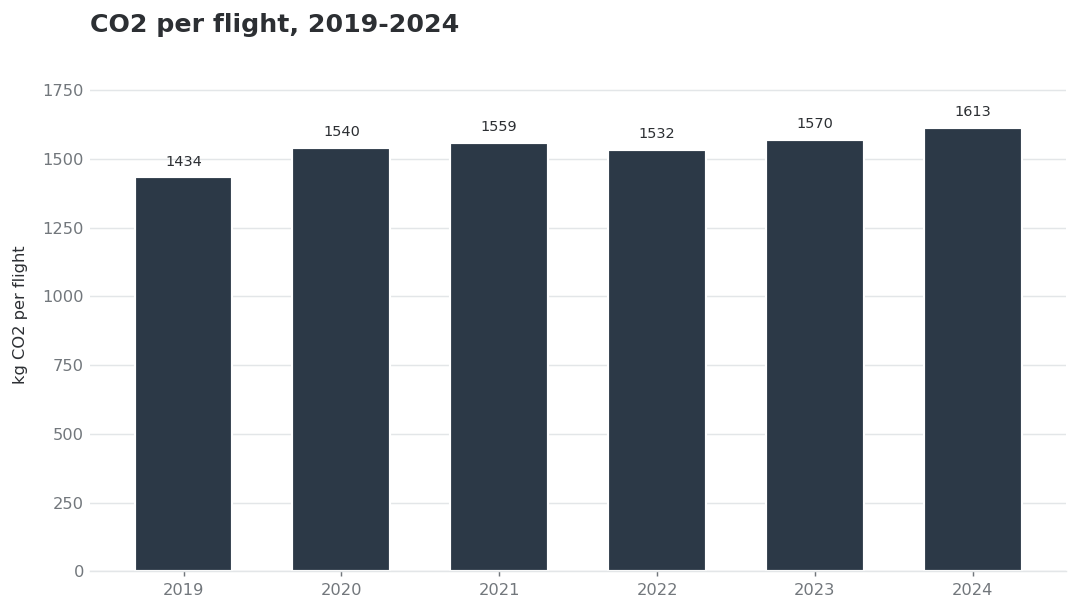

In [18]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
bars = ax.bar(
    yearly_efficiency["YEAR"].astype(str),
    yearly_efficiency["co2_kg_per_flight"],
    color=BAR_BLUE,
    edgecolor="white",
    linewidth=1.2,
    width=0.62,
)
ax.set_ylim(0, eff_max * 1.16)
ax.set_ylabel("kg CO2 per flight")
ax.set_title("CO2 per flight, 2019-2024", loc="left", pad=14)
ax.grid(axis="y", color=LINE, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(LINE)
ax.tick_params(axis="y", length=0)

for bar, val in zip(bars, yearly_efficiency["co2_kg_per_flight"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 32,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color=DARK,
    )
'''
ax.text(
    0.01,
    -0.18,
    f"Lie factor = graphic effect / data effect = {eff_data_effect:.2f} / {eff_data_effect:.2f} = {eff_white_lie_factor:.2f}",
    transform=ax.transAxes,
    fontsize=8,
    color=MUTED,
)
'''
plt.tight_layout()
save_figure(fig, "whitehat_yearly_co2_per_flight")
plt.show()


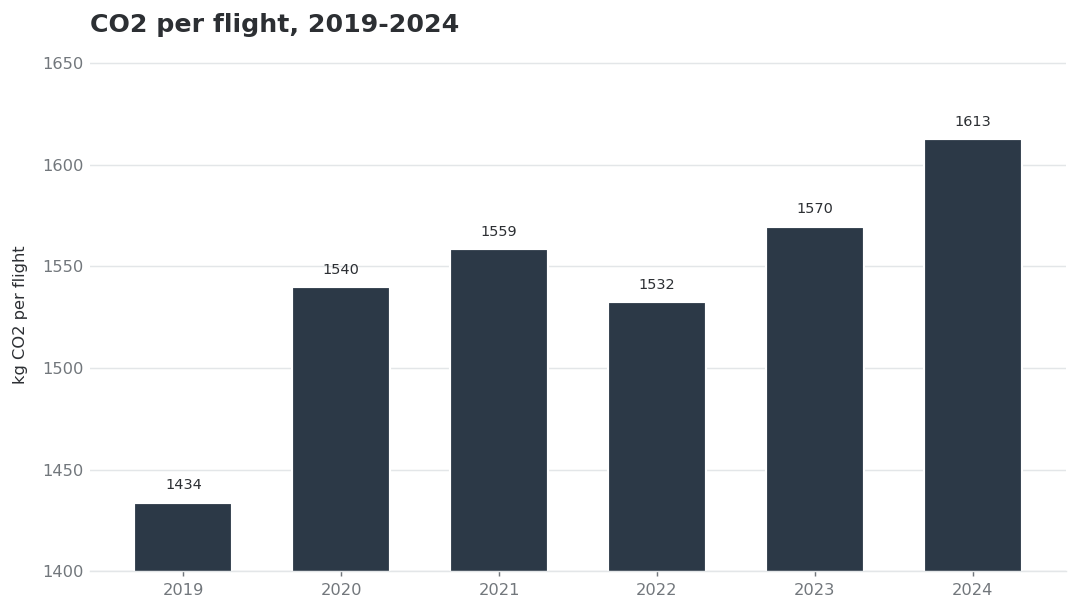

In [19]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
bars = ax.bar(
    yearly_efficiency["YEAR"].astype(str),
    yearly_efficiency["co2_kg_per_flight"],
    color=BAR_BLUE,
    edgecolor="white",
    linewidth=1.2,
    width=0.62,
)
ax.set_ylim(eff_truncate_at, eff_max * 1.025)
ax.set_ylabel("kg CO2 per flight")
ax.set_title("CO2 per flight, 2019-2024", loc="left", pad=14)
ax.grid(axis="y", color=LINE, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(LINE)
ax.tick_params(axis="y", length=0)

for bar, val in zip(bars, yearly_efficiency["co2_kg_per_flight"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 5,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color=DARK,
    )
'''
ax.text(
    0.01,
    -0.18,
    f"Lie factor = graphic effect / data effect = {eff_black_graphic_effect:.2f} / {eff_data_effect:.2f} = {eff_black_lie_factor:.2f}",
    transform=ax.transAxes,
    fontsize=8,
    color=MUTED,
)
'''
plt.tight_layout()
save_figure(fig, "blackhat_yearly_co2_per_flight_truncated_axis")
plt.show()


**Comment.** The two plots use exactly the same data: yearly total CO2 divided by yearly total flights. The truthful chart shows the increase from 2019 to 2024 as real but moderate: about 1,434 kg CO2 per flight to about 1,613 kg CO2 per flight, or roughly 1.12x.

The misleading chart compresses the vertical scale by starting it at 1,400 kg. No data points are removed and no values are changed, but the visual distance is inflated. The data effect is `(1612.59 - 1433.76) / 1433.76 = 0.12`. The graphic effect after truncation is `(1612.59 - 1433.76) / (1433.76 - 1400.00) = 5.30`. Therefore the lie factor is `5.30 / 0.12 = 42.47`.